In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

In [2]:
data_root = '/astrum/home/hpchzy/code/data/'


hostname = 'c920bn3'
# hostname = 'cgnr6760pn2'
# hostname = 'camd9554n2'

# date_base = '20260423' # sampBase+filtOpt
# output = 'output'

date_base = '20260512' # sampOpt+filtOpt
output = 'output_sampOpt_filtOpt'

kernel = "jacobi2d5p"
# kernel = "tl_f90_cg_calc_w"

iarr = 1024

data_path = os.path.join(data_root, f'{date_base}/{hostname}/{output}')

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}

data_path

'/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt'

# ER EP

In [3]:
print(date_base)
print(kernel)
print(hostname)
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}*n*{hostname}_filt/'))

# metric_df = pd.DataFrame(columns=['timer', 'iarr', 'er', 'ep', 'wd'])
print(filt_folders)
metric_list = []
for filt_folder in filt_folders:
    groups = re.search(f'{kernel}([0-9]+)n.*_(.*)_{hostname}_filt/', filt_folder)
    iarr = int(groups.group(1))
    timer = groups.group(2)
    with open(filt_folder + '/er.out', 'r') as f:
        er = f.read()
        f.close()
    with open(filt_folder + '/ep.out', 'r') as f:
        ep = f.read()
        f.close()
    with open(filt_folder + '/wd.out', 'r') as f:
        wd = f.read()
        f.close()
    metric_list.append({'timer': timer, 'iarr': iarr, 'er': er, 'ep': ep, 'wd': wd})

metric_df = pd.DataFrame(metric_list)
metric_df = metric_df[metric_df['timer'] != 'likwid']
metric_df.sort_values(by=['timer','iarr'], inplace=True)

result = metric_df.loc[metric_df.groupby('timer')['er'].idxmax()]
result
metric_df


20260512
jacobi2d5p
c920bn3
['/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papix6_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvct_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvct_fence_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cgt_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papi_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvcto_c920bn3_filt/']


,timer,iarr,er,ep,wd
3,cgt,1024,0.449452,0.970166,7320.072362
1,cntvct,1024,0.161233,0.527239,2504.333668
5,cntvcto,1024,0.442189,0.975506,7042.964824
2,fence,1024,1.000000,inf,15897.095477
4,papi,1024,0.252837,0.791687,4101.373869
0,papix6,1024,0.246362,0.840705,3952.656281


# Filt

In [4]:
iarr = 1024
print(iarr)
print(kernel)
print(hostname)
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))



timer_dict = {}
print(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))
print(filt_folders)

for filt_folder in filt_folders:
    timer = re.search(f'{kernel}{iarr}n.*_(.*)_{hostname}_filt/', filt_folder).group(1)
    print(filt_folder)
    if timer == 'likwid':
        continue
    
    tm_hist_path = os.path.join(filt_folder, 'tm_hist.csv')
    tm_hist_df = pd.read_csv(tm_hist_path, header=None)
    tm_hist_df.columns = ['ns', 'pr']
    tm_hist_df['ns'] = pd.to_numeric(tm_hist_df['ns'], errors='coerce')
    tm_hist_df['pr'] = pd.to_numeric(tm_hist_df['pr'], errors='coerce')
    tm_hist_df = (
        tm_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )

    tr_hist_path = os.path.join(filt_folder, 'tr_hist.csv')
    tr_hist_df = pd.read_csv(tr_hist_path, header=None)
    tr_hist_df.columns = ['ns', 'pr']
    tr_hist_df['ns'] = pd.to_numeric(tr_hist_df['ns'], errors='coerce')
    tr_hist_df['pr'] = pd.to_numeric(tr_hist_df['pr'], errors='coerce')
    tr_hist_df = (
        tr_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )

    # tf_folder = re.sub(r'_filt/?$', '_tf', filt_folder.rstrip('/'))
    tf_folder = re.sub(r'_filt/?$', '', filt_folder.rstrip('/'))
    tf_dfs = []
    for tf_file in sorted(glob.glob(os.path.join(tf_folder, '*.csv'))):
        tf_df = pd.read_csv(tf_file, header=None, usecols=[1])
        tf_dfs.append(tf_df)
    if tf_dfs:
        tf_cdf_df = pd.concat(tf_dfs, ignore_index=True)
        tf_cdf_df.columns = ['ns']
        tf_cdf_df['ns'] = pd.to_numeric(tf_cdf_df['ns'], errors='coerce')
        tf_cdf_df = (
            tf_cdf_df.dropna(subset=['ns'])
            .sort_values('ns', kind='stable')
            .reset_index(drop=True)
        )
        tf_cdf_df['cdf'] = (tf_cdf_df.index + 1) / len(tf_cdf_df)
        quantile_val = tf_cdf_df['cdf'].quantile(0.995)
        tf_cdf_df = tf_cdf_df[tf_cdf_df['cdf'] < quantile_val]
    else:
        tf_cdf_df = pd.DataFrame({'ns': [], 'cdf': []})

    tm_cdf_df = tm_hist_df.assign(cdf=tm_hist_df['pr'].cumsum())
    tr_cdf_df = tr_hist_df.assign(cdf=tr_hist_df['pr'].cumsum())

    timer_dict[timer] = {
        'tm_cdf_df': tm_cdf_df,
        'tr_cdf_df': tr_cdf_df,
        'tf_cdf_df': tf_cdf_df
    }

    # fig, ax = pyplot.subplots(figsize=(10, 5))
    # ax.plot(tm_cdf_df['ns'], tm_cdf_df['cdf'], label='tm_cdf')
    # ax.plot(tr_cdf_df['ns'], tr_cdf_df['cdf'], label='tr_cdf')
    # ax.set_xlabel('ns')
    # ax.set_ylabel('cdf')
    # ax.set_title(timer)
    # ax.grid(True, alpha=0.3)
    # ax.legend()

    # print(tm_hist_df.head())
    # print(tr_hist_df.tail())


1024
jacobi2d5p
c920bn3
/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n*c920bn3_filt/
['/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papix6_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvct_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvct_fence_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cgt_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papi_c920bn3_filt/', '/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cntvcto_c920bn3_filt/']
/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papix6_c920bn3_filt/
/astrum/home/hpchzy/code/data/20260512/c920bn3/output_sampOpt_filtOpt/jacobi2d

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


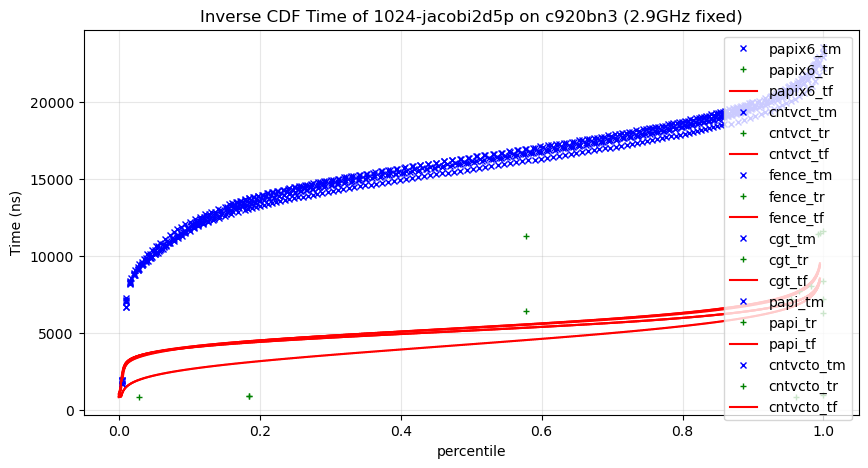

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
color_list = ['red', 'blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'lime', 'teal', 'navy', 'maroon', 'gold', 'silver', 'indigo', 'turquoise', 'coral']
for i, timer in enumerate(timer_dict.keys()):
    # if timer != 'cntvct':
    #     continue
    # if timer not in ['tsc']:
    #     continue

    ax.plot(timer_dict[timer]['tm_cdf_df']['cdf'], timer_dict[timer]['tm_cdf_df']['ns'], label=f'{timer}_tm', color='blue', linestyle='None', marker='x', markersize=5)
    ax.plot(timer_dict[timer]['tr_cdf_df']['cdf'], timer_dict[timer]['tr_cdf_df']['ns'], label=f'{timer}_tr', color='green', linestyle='None', marker='+', markersize=5)
    ax.plot(timer_dict[timer]['tf_cdf_df']['cdf'], timer_dict[timer]['tf_cdf_df']['ns'], label=f'{timer}_tf', color='red', linestyle='-', linewidth=1.5)

ax.set_xlabel('percentile')
ax.set_ylabel('Time (ns)')
ax.set_title(f'Inverse CDF Time of {iarr}-{kernel} on {hostname} ({freq_dict[hostname]}GHz fixed)')
ax.grid(True, alpha=0.3)

ax.legend()